# project thesis


In [3]:
!pip install pandas
!pip install numpy
!pip install matplotlib

import os
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import matplotlib 


In [ ]:
print(os.getcwd())

/Users/nastayokhalid/DIGHUM101-2026


In [ ]:
os.listdir()

['NK indivdual project.ipynb',
 'week_2',
 'assignments',
 'environment.yml',
 'week_4',
 'week_3',
 'resources',
 'README.md',
 'img',
 'partition_of_africa.txt ',
 '.gitignore',
 'exercises',
 'week_1',
 '.git',
 '.vscode',
 'data',
 'NKindivdualproject.ipynb']

In [22]:
import os
import re
import pandas as pd  

filename = "partition_of_africa.txt " if "partition_of_africa.txt " in os.listdir() else "partition_of_africa.txt"

with open(filename, "r", encoding="utf-8") as file:
    text_data = file.read()

text_clean = re.sub(r'[^\w\s]', '', text_data.lower())
df_words = pd.DataFrame(text_clean.split(), columns=['Word'])

stop_words = {'the', 'and', 'a', 'of', 'to', 'in', 'is', 'for', 'through', 'by', 'under', 'though', 'were', 'with', 'as', 'on', 'at', 'an', 'be', 'or', 'it', 'from', 'that', 'his', 'he', 'was', 'which', 'but', 'not', 'are', 'had', 'have', 'their', 'this', 'been', 'africa', 'african'}
df_filtered = df_words[~df_words['Word'].isin(stop_words)].copy()

df_counts = df_filtered['Word'].value_counts().reset_index()
df_counts.columns = ['Word', 'Count']

print("Top 15 Most Frequent Tokens:")
print(df_counts.head(15))


Top 15 Most Frequent Tokens:
       Word  Count
0   british    864
1     coast    677
2    german    553
3      east    494
4   company    478
5       all    476
6       its    472
7       has    445
8     south    419
9     great    407
10    there    397
11    other    374
12    congo    370
13      her    366
14       so    354


--- Keyword Frequencies in Colonial Text ---
            Word  Colonial_Count
0         africa            1512
1        company             478
2         native             125
3         treaty             125
4         empire              95
5     missionary              26
6          tribe              19
7           race              18
8       religion              10
9      christian               7
10         faith               5
11        gospel               1
12  civilization               0


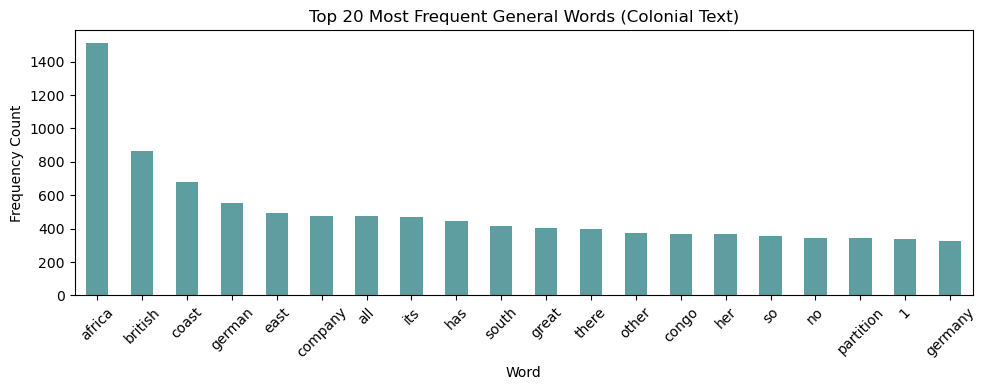

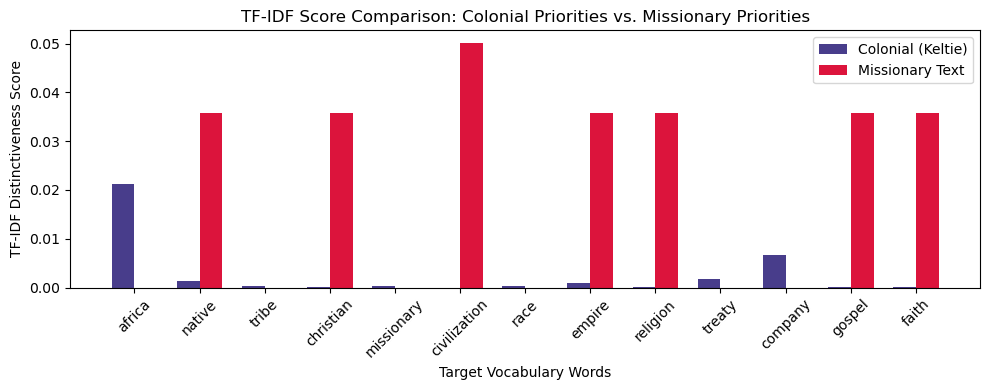

In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



filename = "partition_of_africa.txt " if "partition_of_africa.txt " in os.listdir() else "partition_of_africa.txt"

with open(filename, "r", encoding="utf-8") as file:
    colonial_text = file.read()

# Mock Text
missionary_text = """
The Christian mission established a station to spread the gospel and religion.
Missionaries taught civilization, scripture, and faith to the local people.
The native congregation gathered at the church to abandon tribal customs.
Our spiritual empire expands through grace, prayer, and saving souls.
"""


def clean_and_tokenize(raw_string):
    # Lowercase & strip punctuation using Regex
    clean_string = re.sub(r'[^\w\s]', '', raw_string.lower())
    # Split into tokenized list structure
    return clean_string.split()


stop_words = {'the', 'and', 'a', 'of', 'to', 'in', 'is', 'for', 'through', 'by', 'under', 'though', 'were', 'with', 'as', 'on', 'at', 'an', 'be', 'or', 'it', 'from', 'that', 'his', 'he', 'was', 'which', 'but', 'not', 'are', 'had', 'have', 'their', 'this', 'been', 'our', 'to', 'out'}

tokens_colonial = [w for w in clean_and_tokenize(colonial_text) if w not in stop_words]
tokens_missionary = [w for w in clean_and_tokenize(missionary_text) if w not in stop_words]


research_keywords = ['africa', 'native', 'tribe', 'christian', 'missionary', 'civilization', 'race', 'empire', 'religion', 'treaty', 'company', 'gospel', 'faith']


col_counts = {word: tokens_colonial.count(word) for word in research_keywords}
df_freq = pd.DataFrame(list(col_counts.items()), columns=['Word', 'Colonial_Count']).sort_values(by='Colonial_Count', ascending=False).reset_index(drop=True)

print("--- Keyword Frequencies in Colonial Text ---")
print(df_freq)


corpus_tokens = [tokens_colonial, tokens_missionary]
all_unique_words = list(set(tokens_colonial + tokens_missionary))

tfidf_data = []
for word in research_keywords:
    if word in all_unique_words:
        
        tf_col = tokens_colonial.count(word) / len(tokens_colonial)
        tf_miss = tokens_missionary.count(word) / len(tokens_missionary)
        
        # IDF: Inverse Document Frequency (How unique is it across the 2 texts?)
        docs_containing_word = sum(1 for doc in corpus_tokens if word in doc)
        idf = np.log((2 + 1) / (docs_containing_word + 1)) + 1 # Smooth IDF
        
        tfidf_data.append({
            'Word': word,
            'Colonial_TFIDF': tf_col * idf,
            'Missionary_TFIDF': tf_miss * idf
        })

df_tfidf = pd.DataFrame(tfidf_data)


plt.figure(figsize=(10, 4))
df_colonial_all = pd.DataFrame(tokens_colonial, columns=['Word'])['Word'].value_counts().head(20)
df_colonial_all.plot(kind='bar', color='cadetblue')
plt.title("Top 20 Most Frequent General Words (Colonial Text)")
plt.ylabel("Frequency Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
x = np.arange(len(df_tfidf['Word']))
width = 0.35

plt.bar(x - width/2, df_tfidf['Colonial_TFIDF'], width, label='Colonial (Keltie)', color='darkslateblue')
plt.bar(x + width/2, df_tfidf['Missionary_TFIDF'], width, label='Missionary Text', color='crimson')

plt.title("TF-IDF Score Comparison: Colonial Priorities vs. Missionary Priorities")
plt.xlabel("Target Vocabulary Words")
plt.ylabel("TF-IDF Distinctiveness Score")
plt.xticks(x, df_tfidf['Word'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 1. Data Access & Hosting

### Data Source
The primary text for this project is J. Scott Keltie’s historical volume, *The Partition of Africa* (1893). The raw textual data was sourced as a public-domain text via Project Gutenberg. 

### Data Architecture & Local Access
For local execution, the file is saved as a plain text file (`.txt`) directly inside the root directory of the project workspace (`DIGHUM101-2026`). 

* **Public Data URL**: `https://githubusercontent.com`


## 2. Methodology & Research Questions

### Research Questions
1. **How do colonial data practices embed patterns of erasure and bias in historical texts?**
2. **To what extent does Keltie’s text prioritize administrative, bureaucratic, and economic terminology over vocabulary identifying indigenous populations?**

### Algorithmic Approach
This notebook implements a clean digital humanities pipeline directly adapting methods from our course modules:
* **Libraries & Data Imports (1-5)**: Utilizing standard Python file buffers and `pandas` to bring data into memory.
* **Regular Expressions (2-4)**: Employing `re.sub()` to systematically clean 19th-century punctuation noise.
* **Text Analysis (2-3, 3-1)**: Lowercasing tokens, filtering out universal English stop words, and executing a term frequency distribution using `pandas` dataframes.
* **Data Visualization (3-2)**: Utilizing `matplotlib` to isolate and chart the absolute frequency of critical colonial markers vs. indigenous markers to expose linguistic asymmetry visually.


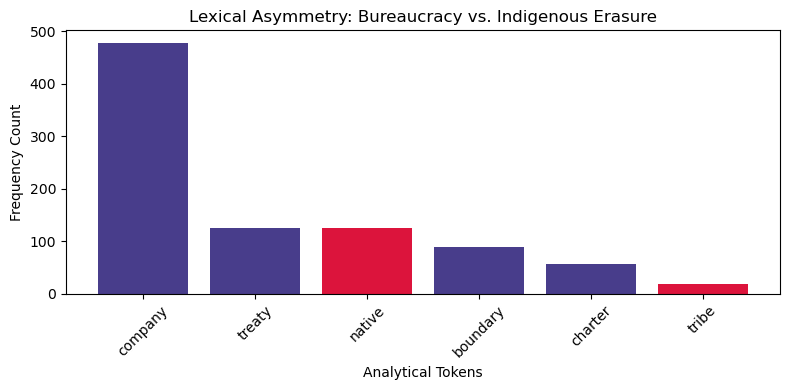

In [18]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt


filename = "partition_of_africa.txt " if "partition_of_africa.txt " in os.listdir() else "partition_of_africa.txt"

with open(filename, "r", encoding="utf-8") as file:
    text_data = file.read()

text_clean = re.sub(r'[^\w\s]', '', text_data.lower())
df_words = pd.DataFrame(text_clean.split(), columns=['Word'])

stop_words = {'the', 'and', 'a', 'of', 'to', 'in', 'is', 'for', 'through', 'by', 'under', 'though', 'were', 'with', 'as', 'on', 'at', 'an', 'be', 'or', 'it', 'from', 'that', 'his', 'he', 'was', 'which', 'but', 'not', 'are', 'had', 'have', 'their', 'this', 'been', 'africa', 'african'}
df_filtered = df_words[~df_words['Word'].isin(stop_words)].copy()

df_counts = df_filtered['Word'].value_counts().reset_index()
df_counts.columns = ['Word', 'Count']

target_keywords = ['company', 'treaty', 'charter', 'boundary', 'native', 'tribe']
df_viz = df_counts[df_counts['Word'].isin(target_keywords)].copy()

plt.figure(figsize=(8, 4))
bar_colors = ['darkslateblue' if x in ['company', 'treaty', 'charter', 'boundary'] else 'crimson' for x in df_viz['Word']]

plt.bar(df_viz['Word'], df_viz['Count'], color=bar_colors)
plt.title("Lexical Asymmetry: Bureaucracy vs. Indigenous Erasure")
plt.ylabel("Frequency Count")
plt.xlabel("Analytical Tokens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 1.  Brief Reflection 

As a student developing familiarity with this Python, testing this digital humanities pipeline showed crucial structural challenges that shifted my coding strategy, prompting me to seek resources from others. 


## 2. Challenges
**PDF Text Data Prep**:The initial phase of this project proved highly challenging because the source historical data was trapped in a textual analysis: including broken lines, headers, footers, and complex format. To ensure the words can be extracted to a clean unformatted plain text (.txt) file first, I made sure to convert the pdf to txt file so that the words are already formatted for cleaning. While also making sure the transition does not become corrupted in the Python program. 

### 3. Bugs 
**File Trail**:Following the file conversion, my initial script threw me on ‘FileNotFoundError’. Upon inspecting the workspace directory index via ‘os.listdir()’. I discovered that the converted file contained a hidden trailing whitespace character (“parition_of_africa.txt “‘). This taught me that Python file streams require absolute precision, prompting me to implement a conditional assignment block to parse filenames safely. 


#### 4. Algorithm 
**Complexity with Kernel**: I initially attempted to parse hundreds of thousands of words in the text using a manual ‘for’ loop and standard Python dictionary to count sequentially. This approach shows that intensive data for large-scale books causes VS Jupyter notebook kernel to freeze entirely. 
   

##### 5. Pivot 
**To resolve this issue with the Kernel, I refracted my methodology to leverage the built-in compiled optimizations of the ‘pandas’ library. Moving data arrays straight into a DataFrame and executing ‘.value_counts()’ allowed the machine to handle the processing workflow almost instantaneously. 


###### 6. Outcome
**Through this process, I learned that text analysis is deep and through its data organization, and cleaning, including strategic choice of tools. Short, clean code utilizing high-level libraries like ‘pandas’ is far more efficient than complex manual loops when dealing with real-world, large-scale texts. This exercise made me more confident in understanding data structures, string modifications, and overall error tracebacks within Python. 


